<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/09_Text_Processing_and_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Text Processing and Multiclass Classification**

This notebook covers Text Processing and Multiclass Classification:

1. Introduction to Text Processing
2. Text Vectorization Techniques (BoW and TF-IDF)
3. Feature Extraction from Text (N-grams, POS Tagging, NER)
4. Implementing Text Classification Models
5. Multiclass Classification Strategies (OvR and OvO)
6. Evaluating Text Models

# **1. Introduction to Text Processing**

Between 80–90% of the world's data is **unstructured** — the most common form being text. Computers cannot inherently interpret text, so before any ML algorithm can process it, raw text must be converted into a structured numerical representation.

## **1.1 Core Challenge**

Text data is:
- High-dimensional (vocabulary can be enormous)
- Sparse (most words don't appear in any given document)
- Noisy (punctuation, casing, stopwords, typos)
- Context-dependent (word meaning shifts with surrounding words)

## **1.2 Key Preprocessing Steps**

| Step | Purpose |
|---|---|
| **Tokenization** | Split text into individual tokens (words, subwords) |
| **Stop word removal** | Remove high-frequency, low-information words (the, a, is) |
| **Lowercasing** | Normalize case to reduce vocabulary size |
| **Stemming / Lemmatization** | Reduce words to their root forms |
| **Vectorization** | Convert tokens into numerical feature vectors |

## **1.3 Text as a Corpus**

In NLP, a collection of text documents used for modeling is called a **corpus**. Each document in the corpus becomes one row in the feature matrix after vectorization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Download required NLTK corpus
try:
    from nltk.corpus import movie_reviews
    movie_reviews.sents()
except LookupError:
    nltk.download('movie_reviews')
    from nltk.corpus import movie_reviews

# Load corpus
documents, labels = [], []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents.append(movie_reviews.raw(fileid))
        labels.append(category)

# Encode labels numerically
label_map = {label: i for i, label in enumerate(sorted(set(labels)))}
numerical_labels = [label_map[l] for l in labels]

# Stratified subsample for speed
texts_subset, _, labels_subset, _ = train_test_split(
    documents, numerical_labels,
    train_size=500, stratify=numerical_labels, random_state=2024
)

X_train, X_test, y_train, y_test = train_test_split(
    texts_subset, labels_subset,
    test_size=0.3, stratify=labels_subset, random_state=2024
)

print(f"Corpus size (subset) : {len(texts_subset)} documents")
print(f"Training set         : {len(X_train)} documents")
print(f"Test set             : {len(X_test)} documents")
print(f"Classes              : {label_map}")


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Corpus size (subset) : 500 documents
Training set         : 350 documents
Test set             : 150 documents
Classes              : {'neg': 0, 'pos': 1}


Vocabulary size (top 20) : 20
Feature matrix shape     : (350, 20)


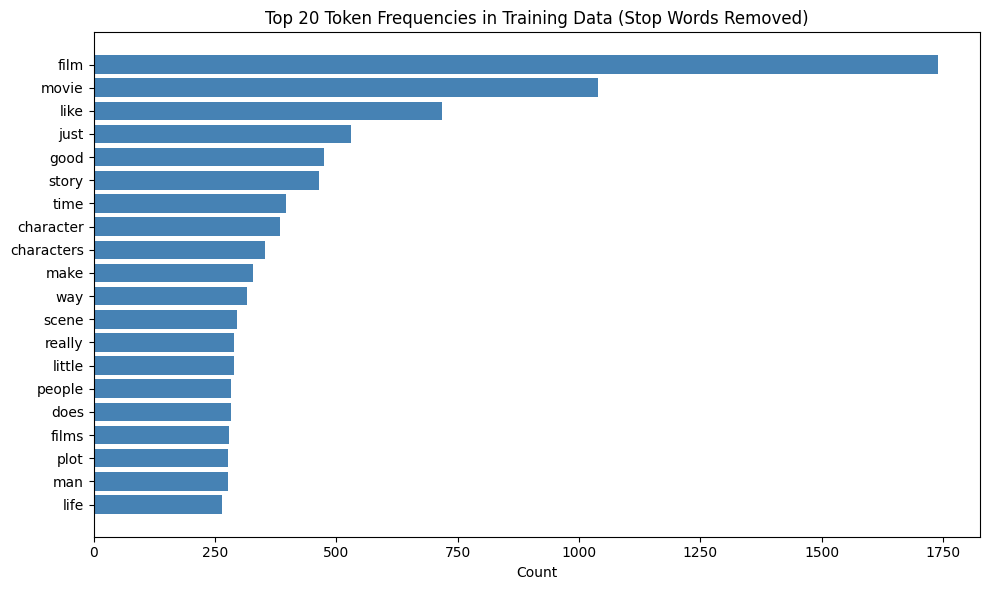

In [2]:
# CountVectorizer: convert text to token frequency matrix
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect  = vectorizer.transform(X_test)

print(f"Vocabulary size (top 20) : {len(vectorizer.get_feature_names_out())}")
print(f"Feature matrix shape     : {X_train_vect.shape}")

# Visualize top token frequencies
feature_names = vectorizer.get_feature_names_out()
counts = X_train_vect.toarray().sum(axis=0)
sorted_idx = np.argsort(counts)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_idx[::-1]], counts[sorted_idx[::-1]], color='steelblue')
plt.xlabel('Count')
plt.title('Top 20 Token Frequencies in Training Data (Stop Words Removed)')
plt.tight_layout()
plt.show()


# **2. Text Vectorization Techniques**

Raw text must be transformed into numerical vectors before ML models can process it. Two foundational approaches are used throughout this chapter:

## **2.1 Bag of Words (BoW)**

`CountVectorizer` creates a **term-frequency matrix** — each document becomes a vector of word counts. Word order and grammar are completely discarded.

$$\text{BoW}(d, w) = \text{count of word } w \text{ in document } d$$

**Limitations:** Treats all words equally; common words dominate even after stop word removal.

## **2.2 TF-IDF (Term Frequency – Inverse Document Frequency)**

`TfidfVectorizer` adjusts raw counts to penalize words that appear frequently across *all* documents (common but uninformative) and reward words that are distinctive to specific documents.

$$\text{TF-IDF}(t, d) = \text{TF}(t,d) \times \log\left(\frac{N}{\text{df}(t)}\right)$$

Where:
- $\text{TF}(t,d)$ = frequency of term $t$ in document $d$
- $N$ = total number of documents
- $\text{df}(t)$ = number of documents containing term $t$

**Advantage:** Highlights discriminative terms; downgrades ubiquitous words.

## **2.3 Word Embeddings (Beyond scikit-learn)**

Dense vector representations (Word2Vec, GloVe, BERT) encode semantic meaning and contextual relationships. While scikit-learn does not generate these natively, externally generated embeddings can be used as feature inputs.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.corpus import reuters

# Download Reuters corpus
try:
    reuters.fileids()
except LookupError:
    nltk.download('reuters')
    from nltk.corpus import reuters

# Load Reuters corpus
doc_ids  = reuters.fileids()
texts_r  = [reuters.raw(d) for d in doc_ids]
labels_r = [reuters.categories(d)[0] for d in doc_ids]

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    texts_r, labels_r, test_size=0.5, random_state=2024
)

# BoW
bow_vec = CountVectorizer()
X_tr_bow = bow_vec.fit_transform(X_tr_r)
X_te_bow  = bow_vec.transform(X_te_r)

# TF-IDF
tfidf_vec = TfidfVectorizer()
X_tr_tfidf = tfidf_vec.fit_transform(X_tr_r)
X_te_tfidf  = tfidf_vec.transform(X_te_r)

print(f"BoW  feature matrix : {X_tr_bow.shape}")
print(f"TF-IDF feature matrix: {X_tr_tfidf.shape}")


[nltk_data] Downloading package reuters to /root/nltk_data...


BoW  feature matrix : (5394, 22864)
TF-IDF feature matrix: (5394, 22864)


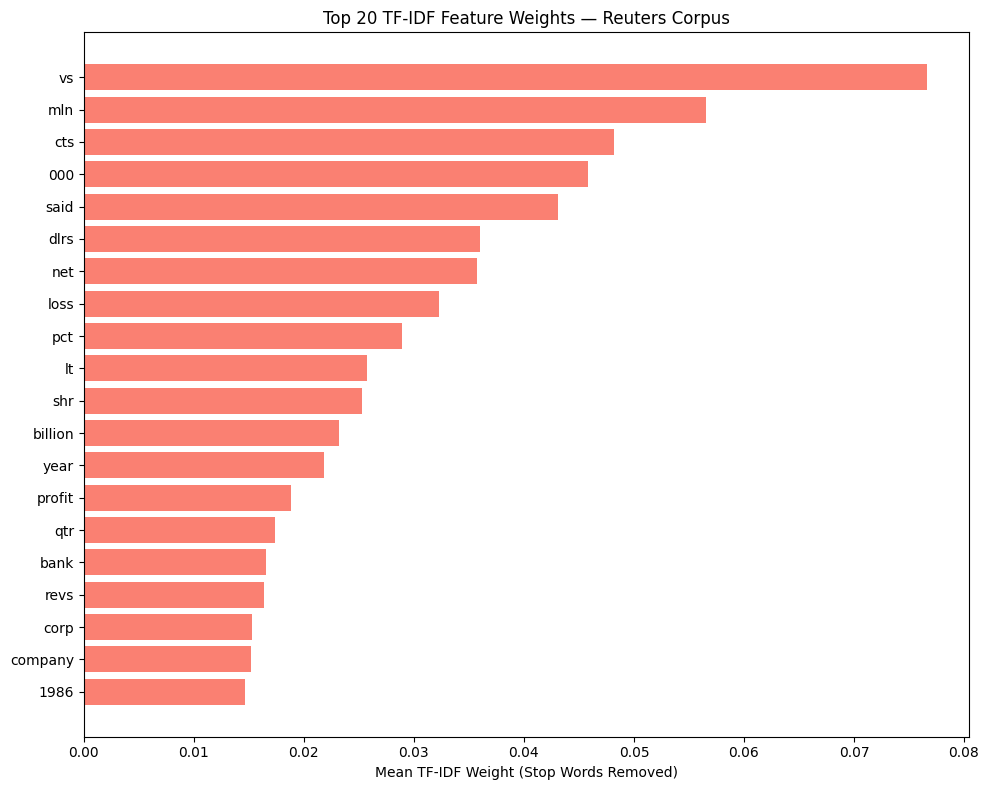

In [4]:
# Visualize top 20 TF-IDF feature weights (stop words removed)
vis_tfidf = TfidfVectorizer(stop_words='english')
X_tr_vis  = vis_tfidf.fit_transform(X_tr_r)
feat_names = vis_tfidf.get_feature_names_out()
tfidf_means = X_tr_vis.toarray().mean(axis=0)

N = 20
top_idx = np.argsort(tfidf_means)[-N:]

plt.figure(figsize=(10, 8))
plt.barh(feat_names[top_idx], tfidf_means[top_idx], color='salmon')
plt.xlabel('Mean TF-IDF Weight (Stop Words Removed)')
plt.title(f'Top {N} TF-IDF Feature Weights — Reuters Corpus')
plt.tight_layout()
plt.show()


# **3. Feature Extraction from Text**

Beyond raw word frequencies, richer structural and linguistic features can be extracted from text:

## **3.1 N-grams**

N-grams capture **sequences of N consecutive words**, preserving local word context that single-word (unigram) approaches miss.

- **Unigram (n=1):** "machine", "learning", "model"  
- **Bigram (n=2):** "machine learning", "learning model"  
- **Trigram (n=3):** "machine learning model"

In `CountVectorizer`, set `ngram_range=(1, 2)` to include both unigrams and bigrams.

## **3.2 Part-of-Speech (POS) Tagging**

POS tagging annotates each word with its grammatical role (noun, verb, adjective, etc.). This gives models access to syntactic structure.

**Common POS Tags:**

| Tag | Meaning |
|---|---|
| NN | Noun (singular) | NNS | Noun (plural) |
| JJ | Adjective | VBD | Verb, past tense |
| NNP | Proper noun | PRP | Pronoun |
| RB | Adverb | IN | Preposition |

## **3.3 Named Entity Recognition (NER)**

NER identifies and classifies named entities in text — persons, organizations, locations, dates — enriching textual data with factual structure.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import brown
from nltk.util import ngrams as nltk_ngrams
from collections import Counter

# Download NLTK resources
for resource in ['brown', 'punkt', 'punkt_tab', 'averaged_perceptron_tagger_eng', 'stopwords']:
    try:
        nltk.data.find(f'corpora/{resource}.zip' if resource != 'punkt_tab' else f'tokenizers/{resource}')
    except Exception:
        nltk.download(resource, quiet=True)

from nltk.corpus import brown, stopwords

# Build a tiny Brown corpus sample
categories_to_use = brown.categories()[:2]
texts_b, labels_b = [], []
for i, cat in enumerate(categories_to_use):
    for sent_tokens in brown.sents(categories=cat)[:5]:
        texts_b.append(" ".join(sent_tokens))
        labels_b.append(i)

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    texts_b, labels_b, test_size=0.4, random_state=2024
)

# N-gram extraction
ngram_vec = CountVectorizer(ngram_range=(1, 2))
X_tr_ng = ngram_vec.fit_transform(X_tr_b)
print(f"N-gram vocabulary size (1,2): {X_tr_ng.shape[1]}")
print(f"Sample bigrams: {list(ngram_vec.get_feature_names_out())[:10]}")


N-gram vocabulary size (1,2): 121
Sample bigrams: ['all', 'all of', 'and', 'and never', 'ann', 'ann turner', 'as', 'as by', 'as much', 'asking']


--- POS Tagging of Training Sentences ---

Sentence 1: "He was well rid of her ...."
  Tagged: He/PRP was/VBD well/RB rid/JJ of/IN her/PRP ./. ...

Sentence 2: "But all of this was rationalization ...."
  Tagged: But/CC all/DT of/IN this/DT was/VBD rationalization/NN ./. ...


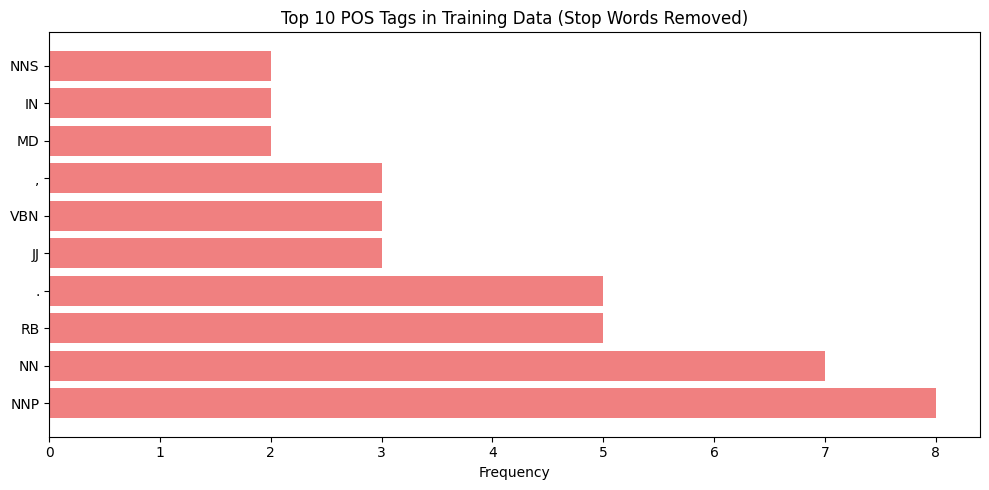

In [6]:
# POS Tagging demonstration
stop_words_set = set(stopwords.words('english'))

print("--- POS Tagging of Training Sentences ---")
for i, text in enumerate(X_tr_b[:2]):
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    print(f"\nSentence {i+1}: \"{text[:80]}...\"")
    print("  Tagged:", " ".join(f"{tok}/{tag}" for tok, tag in pos_tags[:10]), "...")

# POS frequency chart
all_pos_tags = []
for text in X_tr_b:
    tokens = nltk.word_tokenize(text)
    filtered = [t for t in tokens if t.lower() not in stop_words_set]
    if filtered:
        for _, tag in nltk.pos_tag(filtered):
            all_pos_tags.append(tag)

pos_counter = Counter(all_pos_tags)
top_pos = pos_counter.most_common(10)
tags, counts_pos = zip(*top_pos) if top_pos else ([], [])

plt.figure(figsize=(10, 5))
plt.barh(list(tags)[::-1], list(counts_pos)[::-1], color='lightcoral')
plt.xlabel('Frequency')
plt.title('Top 10 POS Tags in Training Data (Stop Words Removed)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# **4. Implementing Text Classification Models**

Once text is vectorized, standard ML classifiers can be applied directly. This section compares three popular algorithms for text classification:

## **4.1 Naive Bayes (MultinomialNB)**

- Based on Bayes' theorem with a "naive" conditional independence assumption
- Highly efficient and naturally suited to discrete count features (BoW)
- Often a strong baseline for text classification despite its simplifying assumptions
- **Weakness:** Cannot model feature interactions

## **4.2 SVM for Text**

- Finds a maximum-margin hyperplane in TF-IDF feature space
- Handles high-dimensional sparse features very well
- Typically one of the strongest single-model approaches for text classification
- **Weakness:** Slower to train than Naive Bayes

## **4.3 Logistic Regression**

- Probabilistic linear classifier; efficient and interpretable
- Coefficient magnitudes reflect relative feature (word) importance
- Good general-purpose baseline with competitive performance

## **4.4 Evaluation Note**

Text classification performance is sensitive to:
- Vectorization strategy (BoW vs. TF-IDF, n-gram range)
- Dataset size and label balance
- Preprocessing quality (stop word removal, stemming)

In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load Brown corpus (all 500 documents, 15 genres)
nltk.download('brown', quiet=True)
doc_ids_b = brown.fileids()
texts_full = [' '.join(brown.words(f)) for f in doc_ids_b]
raw_labels_b = [brown.categories(f)[0] for f in doc_ids_b]

unique_labels = sorted(set(raw_labels_b))
label_to_int = {l: i for i, l in enumerate(unique_labels)}
labels_full = [label_to_int[l] for l in raw_labels_b]

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    texts_full, labels_full,
    test_size=0.5, stratify=labels_full, random_state=2024
)

# TF-IDF vectorization
vec_full = TfidfVectorizer()
X_tr_vf = vec_full.fit_transform(X_tr_f)
X_te_vf  = vec_full.transform(X_te_f)

# Train three classifiers
nb_clf  = MultinomialNB()
svm_clf = SVC(random_state=2024)
lr_clf  = LogisticRegression(random_state=2024, max_iter=1000)

nb_clf.fit(X_tr_vf, y_tr_f)
svm_clf.fit(X_tr_vf, y_tr_f)
lr_clf.fit(X_tr_vf, y_tr_f)

# Accuracy comparison
models = {'Naive Bayes': nb_clf, 'SVM': svm_clf, 'Logistic Regression': lr_clf}
accuracies = {name: accuracy_score(y_te_f, m.predict(X_te_vf)) for name, m in models.items()}

for name, acc in accuracies.items():
    print(f"{name:<22} Accuracy: {acc:.4f}")


Naive Bayes            Accuracy: 0.2280
SVM                    Accuracy: 0.3320
Logistic Regression    Accuracy: 0.3240


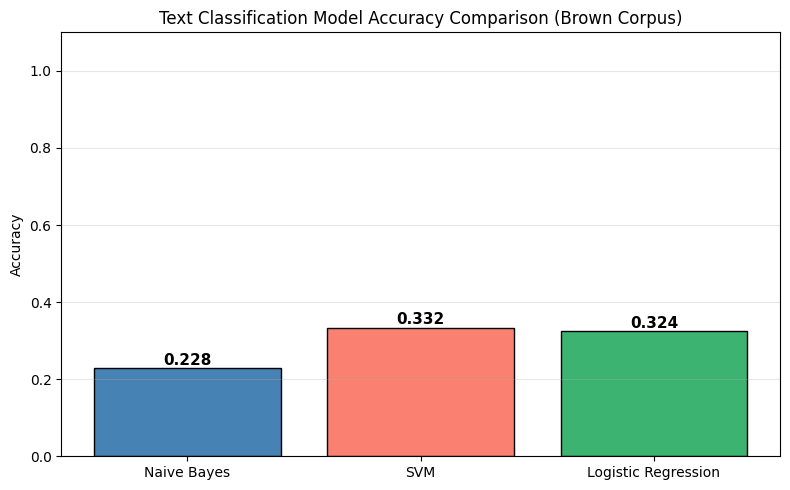


Detailed Report — SVM:
                 precision    recall  f1-score   support

      adventure       0.40      0.13      0.20        15
 belles_lettres       0.24      0.95      0.38        37
      editorial       0.00      0.00      0.00        14
        fiction       0.31      0.36      0.33        14
     government       0.00      0.00      0.00        15
        hobbies       0.00      0.00      0.00        18
          humor       0.00      0.00      0.00         4
        learned       0.42      0.70      0.53        40
           lore       0.00      0.00      0.00        24
        mystery       0.00      0.00      0.00        12
           news       1.00      0.41      0.58        22
       religion       0.00      0.00      0.00         9
        reviews       0.00      0.00      0.00         8
        romance       0.67      0.27      0.38        15
science_fiction       0.00      0.00      0.00         3

       accuracy                           0.33       250
     

In [8]:
# Accuracy bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(accuracies.keys(), accuracies.values(),
               color=['steelblue', 'salmon', 'mediumseagreen'], edgecolor='k')
for bar, acc in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Text Classification Model Accuracy Comparison (Brown Corpus)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Classification report for best model
best_name = max(accuracies, key=accuracies.get)
best_model = models[best_name]
y_pred_best = best_model.predict(X_te_vf)
print(f"\nDetailed Report — {best_name}:")
print(classification_report(y_te_f, y_pred_best,
                             target_names=unique_labels,
                             zero_division=0))


# **5. Multiclass Classification Strategies**

When the target has more than two classes, additional strategies beyond standard logistic regression are available through scikit-learn's `multiclass` module:

## **5.1 One-vs-Rest (OvR)**

For $K$ classes, OvR trains $K$ binary classifiers. Each classifier distinguishes one class from all others. At prediction time, the class whose classifier outputs the highest confidence score wins.

$$\hat{y} = \arg\max_k f_k(\mathbf{x})$$

- Simple, parallelizable, widely supported
- May produce poorly calibrated probabilities for multiclass problems

## **5.2 One-vs-One (OvO)**

For $K$ classes, OvO trains $\binom{K}{2} = \frac{K(K-1)}{2}$ binary classifiers — one for every pair of classes. The final prediction is determined by majority vote.

- More classifiers = more computation, but each is trained on smaller subsets
- Often performs better than OvR on balanced datasets

## **5.3 Practical Guidance**

| Situation | Recommended Strategy |
|---|---|
| Many classes, large dataset | OvR (more efficient) |
| Few classes, balanced dataset | OvO (often better performance) |
| Native multiclass support (e.g., Random Forest) | Use directly — no wrapper needed |

In [9]:
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# Brown corpus: full multiclass setup
vec_mc = TfidfVectorizer()
X_tr_mc = vec_mc.fit_transform(X_tr_f)
X_te_mc  = vec_mc.transform(X_te_f)

# OvR
ovr_clf = OneVsRestClassifier(LogisticRegression(random_state=2024, solver='liblinear'))
ovr_clf.fit(X_tr_mc, y_tr_f)
y_pred_ovr = ovr_clf.predict(X_te_mc)
acc_ovr = accuracy_score(y_te_f, y_pred_ovr)

# OvO
ovo_clf = OneVsOneClassifier(LogisticRegression(random_state=2024, solver='liblinear'))
ovo_clf.fit(X_tr_mc, y_tr_f)
y_pred_ovo = ovo_clf.predict(X_te_mc)
acc_ovo = accuracy_score(y_te_f, y_pred_ovo)

print(f"One-vs-Rest (OvR) Accuracy : {acc_ovr:.4f}")
print(f"One-vs-One  (OvO) Accuracy : {acc_ovo:.4f}")

# Side-by-side report
print("\nOvR Classification Report:")
print(classification_report(y_te_f, y_pred_ovr, target_names=unique_labels, zero_division=0))


One-vs-Rest (OvR) Accuracy : 0.3160
One-vs-One  (OvO) Accuracy : 0.2720

OvR Classification Report:
                 precision    recall  f1-score   support

      adventure       1.00      0.07      0.12        15
 belles_lettres       0.23      0.95      0.36        37
      editorial       0.00      0.00      0.00        14
        fiction       0.00      0.00      0.00        14
     government       0.00      0.00      0.00        15
        hobbies       1.00      0.06      0.11        18
          humor       0.00      0.00      0.00         4
        learned       0.40      0.72      0.52        40
           lore       0.00      0.00      0.00        24
        mystery       0.00      0.00      0.00        12
           news       0.83      0.23      0.36        22
       religion       0.00      0.00      0.00         9
        reviews       0.00      0.00      0.00         8
        romance       0.62      0.53      0.57        15
science_fiction       0.00      0.00      0.

# **6. Evaluating Text Classification Models**

Evaluating text models uses the same metrics as other classifiers, but interpretation requires awareness of **class imbalance** — genres or categories rarely appear with equal frequency in real corpora.

## **6.1 Metric Summary**

| Metric | Formula | Best When |
|---|---|---|
| **Precision** | $\frac{TP}{TP+FP}$ | False positives are costly |
| **Recall** | $\frac{TP}{TP+FN}$ | False negatives are costly |
| **F1-score** | $\frac{2PR}{P+R}$ | Balance between the two |
| **Accuracy** | $\frac{TP+TN}{\text{total}}$ | Balanced classes |

## **6.2 Weighted vs. Macro Averaging**

- **Macro average:** treats all classes equally regardless of frequency  
- **Weighted average:** accounts for class frequency — more meaningful on imbalanced corpora

## **6.3 Confusion Matrix**

A confusion matrix reveals which classes are being systematically confused — critical for diagnosing systematic model errors in multiclass text classification.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from nltk.corpus import movie_reviews
import random

# Reload movie_reviews for binary sentiment evaluation
try:
    movie_reviews.categories()
except LookupError:
    nltk.download('movie_reviews')

docs_mr = []
for cat in movie_reviews.categories():
    for fid in movie_reviews.fileids(cat):
        docs_mr.append((" ".join(movie_reviews.words(fid)), cat))

random.seed(2024)
random.shuffle(docs_mr)

texts_mr  = [d[0] for d in docs_mr]
labels_mr = [d[1] for d in docs_mr]

X_tr_mr, X_te_mr, y_tr_mr, y_te_mr = train_test_split(
    texts_mr, labels_mr, test_size=0.5, random_state=2024
)

# TF-IDF + Logistic Regression
vec_mr = TfidfVectorizer()
X_tr_mr_v = vec_mr.fit_transform(X_tr_mr)
X_te_mr_v  = vec_mr.transform(X_te_mr)

clf_mr = LogisticRegression(random_state=2024, max_iter=1000)
clf_mr.fit(X_tr_mr_v, y_tr_mr)
y_pred_mr = clf_mr.predict(X_te_mr_v)

print(f"Precision (weighted) : {precision_score(y_te_mr, y_pred_mr, average='weighted', zero_division=0):.4f}")
print(f"Recall    (weighted) : {recall_score(y_te_mr, y_pred_mr, average='weighted', zero_division=0):.4f}")
print(f"F1-Score  (weighted) : {f1_score(y_te_mr, y_pred_mr, average='weighted', zero_division=0):.4f}")
print(f"Accuracy             : {accuracy_score(y_te_mr, y_pred_mr):.4f}")


Precision (weighted) : 0.8034
Recall    (weighted) : 0.8030
F1-Score  (weighted) : 0.8030
Accuracy             : 0.8030


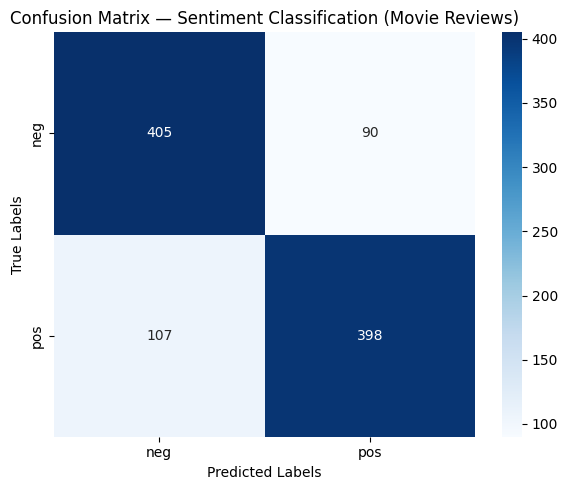

In [11]:
# Confusion matrix
classes_mr = sorted(set(y_te_mr))
cm_mr = confusion_matrix(y_te_mr, y_pred_mr, labels=classes_mr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_mr, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_mr, yticklabels=classes_mr)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix — Sentiment Classification (Movie Reviews)')
plt.tight_layout()
plt.show()
